# Weather Forecasting Using Time Series Analysis

This notebook presents a weather forecasting project focused on predicting daily rainfall in Moscow. The approach combines traditional statistical methods (ARIMA) with neural networks (LSTM) to improve prediction accuracy for rainfall events based on historical weather data.

## Key Steps Covered:
- **Data Preprocessing**: Loading and preparing historical weather data for time series analysis
- **ARIMA Modeling**: Building and tuning an ARIMA model to forecast rainfall
- **LSTM Modeling**: Implementing a deep learning approach using LSTM networks for sequence-based prediction
- **Model Evaluation**: Comparing ARIMA and LSTM predictions and evaluating model performance
- **Forecasting**: Generating rainfall predictions for future days

## 1. Импорты и фиксация случайности
Подключаем всё, что понадобится дальше:
- `pandas` / `numpy` — таблицы и массивы; `matplotlib` / `seaborn` — графики;
- `statsmodels.ARIMA` — классическая статистическая модель для временных рядов;
- `tensorflow.keras` — нейросеть LSTM (и `Layer` для своей функции активации);
- `sklearn` — масштабирование, веса классов, метрика accuracy.

В конце задаём `seed = 42` везде, чтобы результаты обучения воспроизводились от запуска к запуску.

In [44]:
import numpy as np
import random
import tensorflow as tf
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, LSTM, Activation, Layer
from sklearn.utils import class_weight
from tensorflow.keras.callbacks import EarlyStopping

# Set random seed for reproducibility
seed = 42
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

## 2. Загрузка данных
Читаем CSV с погодой (разделитель `;`, кодировка UTF-8). Наблюдения идут **несколько раз в сутки** (каждые 3 часа).
Колонка с временем называется `Местное время в Москве` и хранится строкой вида `31.12.2024 21:00`,
поэтому превращаем её в настоящую дату (`datetime`) и сортируем таблицу по времени.

In [45]:
# Load the weather data
df = pd.read_csv('data.csv', delimiter=';', encoding='utf-8', low_memory=False)

# Convert the 'date' column to datetime format
df['date'] = pd.to_datetime(df['Местное время в Москве'], format="%d.%m.%Y %H:%M")
df = df.sort_values('date')

## 3. Целевая переменная: был ли дождь (0/1)
Колонка `RRR` — количество осадков. Она «грязная»: там бывают текстовые значения («Осадков нет», «Следы осадков») и числа в мм.
Функция `classify_rain` сводит всё к бинарному признаку `rain`:
- «Осадков нет» или пропуск → `0`;
- «Следы осадков» → `1`;
- число больше нуля → `1`, иначе → `0`.

Так задача превращается в **бинарную классификацию**: «будет дождь или нет».

In [46]:
# Create a binary feature for rainfall
def classify_rain(value):
    """Classify the rain value into binary categories."""
    if pd.isna(value) or value == "Осадков нет":
        return 0
    elif value == "Следы осадков":
        return 1
    else:
        try:
            return 1 if float(value) > 0 else 0
        except ValueError:
            return 0

# Apply the classification function to create the 'rain' column
df['rain'] = df['RRR'].apply(classify_rain)

## 4. Агрегация до одной записи в день
Из даты достаём `day`, `month`, `year` и период `month_year` (нужен для группировки по месяцам).
Затем оставляем **одну строку на сутки**: `groupby(год, месяц, день)['rain'].idxmax()` берёт наблюдение с максимальным `rain`.
То есть день считается дождливым, если дождь зафиксирован **хотя бы в одном** из его наблюдений.
После этого временной ряд становится дневным: одна точка = один день.

In [47]:
# Convert the 'date' column to datetime if not already in datetime format
df['date'] = pd.to_datetime(df['date'])

# Create a 'month_year' column
df['month_year'] = df['date'].dt.to_period('M')

# Extract day, month, and year
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

# Drop duplicates by day
df = df.loc[df.groupby(['year', 'month', 'day'])['rain'].idxmax()]

## 5. Разведочный анализ: тепловая карта по месяцам
Считаем долю дождливых дней в каждом месяце каждого года и раскладываем в таблицу «год × месяц».
На тепловой карте (`heatmap`) тёмнее = больше дождливых дней. Здесь видна **сезонность**:
в какие месяцы дожди бывают чаще, и как это меняется от года к году.

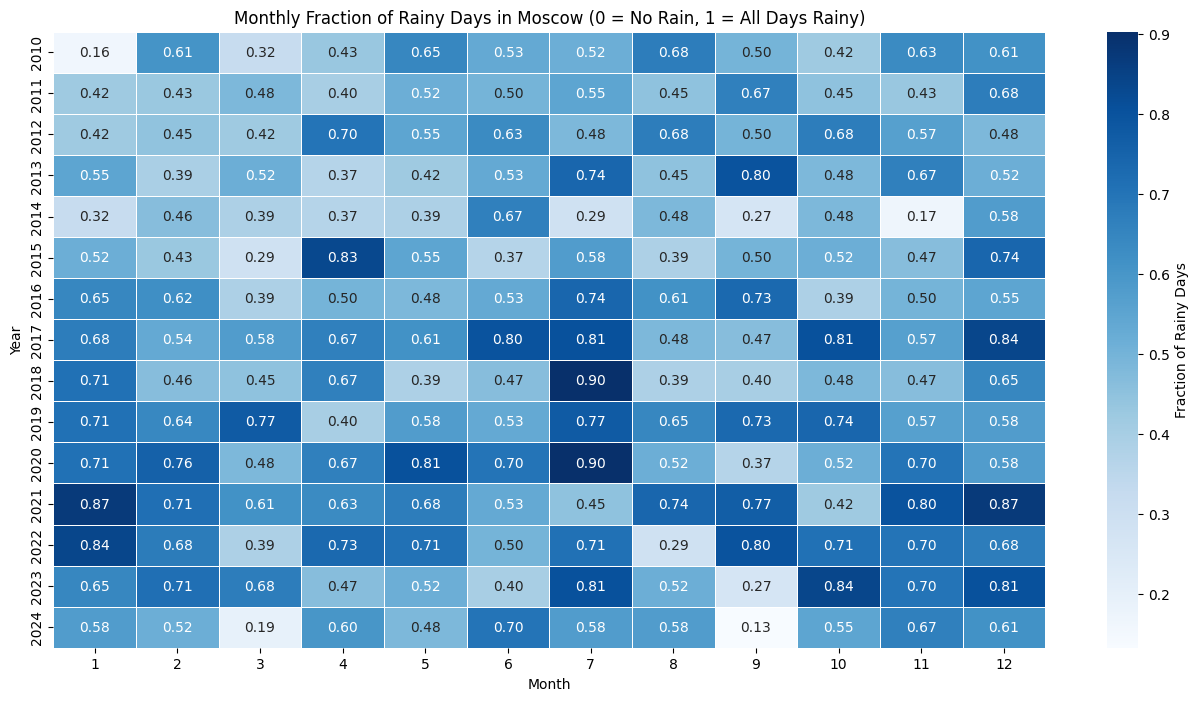

In [48]:
# Calculate the monthly average of rainy days
monthly_rainfall = df.groupby('month_year')['rain'].mean().reset_index()

# Extract year and month separately
monthly_rainfall['year'] = monthly_rainfall['month_year'].dt.year
monthly_rainfall['month'] = monthly_rainfall['month_year'].dt.month

# Pivot the data for heatmap
rain_pivot = monthly_rainfall.pivot(index="year", columns="month", values="rain")

# Plot the heatmap
plt.figure(figsize=(16, 8))
sns.heatmap(rain_pivot, cmap="Blues", cbar_kws={'label': 'Fraction of Rainy Days'}, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Monthly Fraction of Rainy Days in Moscow (0 = No Rain, 1 = All Days Rainy)")
plt.xlabel("Month")
plt.ylabel("Year")
plt.show()

## 6. Разведочный анализ: тренд
Линия — скользящее среднее `rain` за 30 дней: сглаживает шум и показывает, как вероятность дождя плавно меняется во времени
(сезонные волны и возможный тренд).

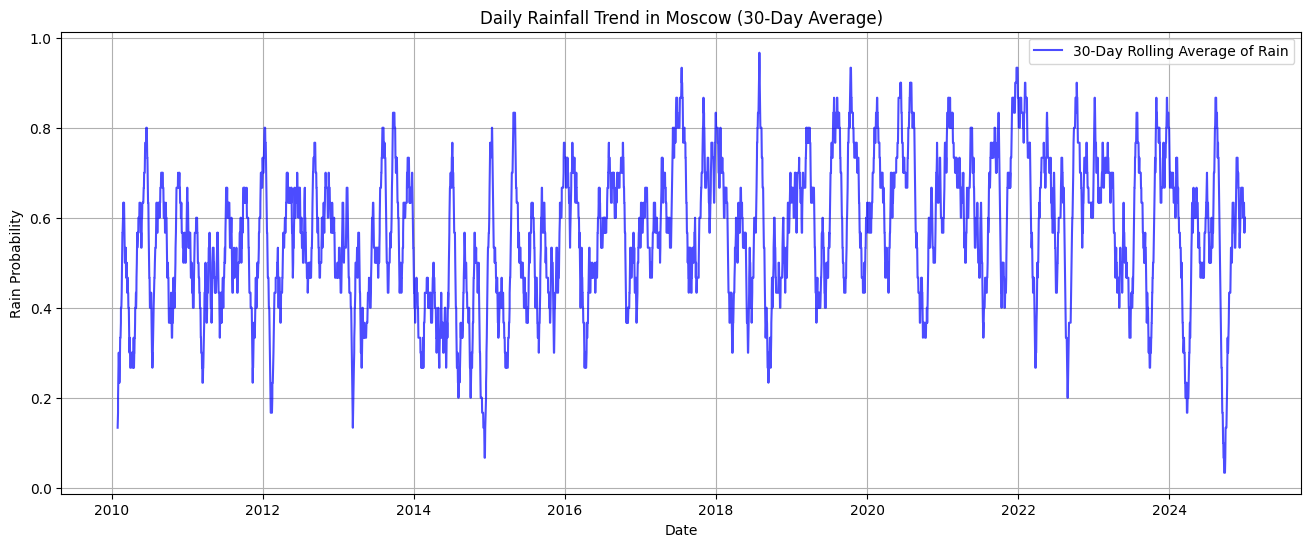

In [49]:
# Optional: Additional line plot for yearly trend
plt.figure(figsize=(16, 6))
plt.plot(df['date'], df['rain'].rolling(window=30).mean(), color="blue", alpha=0.7, label='30-Day Rolling Average of Rain')
plt.title('Daily Rainfall Trend in Moscow (30-Day Average)')
plt.xlabel('Date')
plt.ylabel('Rain Probability')
plt.legend()
plt.grid(True)
plt.show()

## 6а. Замечание: в данных есть сдвиг режима (недельный таймфрейм)
Чтобы увидеть, нет ли в данных «смены поведения», считаем число дождливых дней **по неделям** (одна точка = одна неделя, от 0 до 7) и рисуем три вещи: сами недели, скользящее среднее за 26 недель и среднее по трём периодам.

**Что видно:** в 2010–2016 в среднем ≈3.6 дождливых дня в неделю, в 2017–2023 уже ≈4.4 (примерно +23%), а в 2024 году снова ≈3.6. То есть ряд **нестационарен**: у него «плавает» среднее.

**Почему это важно для моделей:**
- ARIMA с `d=0` предполагает постоянное среднее, а здесь оно меняется;
- тестовая выборка (последние 5% ≈ апрель–декабрь 2024) оказывается в другом режиме, чем 2017–2023 в конце обучения, поэтому качество зависит от того, где провести границу train/test;
- нельзя опираться на один тест из ≈270 дней: статистическая погрешность accuracy там около ±3 п.п. Ниже мы проверяем модели на нескольких годах подряд.

Возможная причина сдвига — сами данные (реанализ ERA5), а не реальный рост числа дождей. Мы это не проверяли.

2010–2016: 3.57 дождливых дней в неделю
2017–2023: 4.40 дождливых дней в неделю
2024–2024: 3.60 дождливых дней в неделю


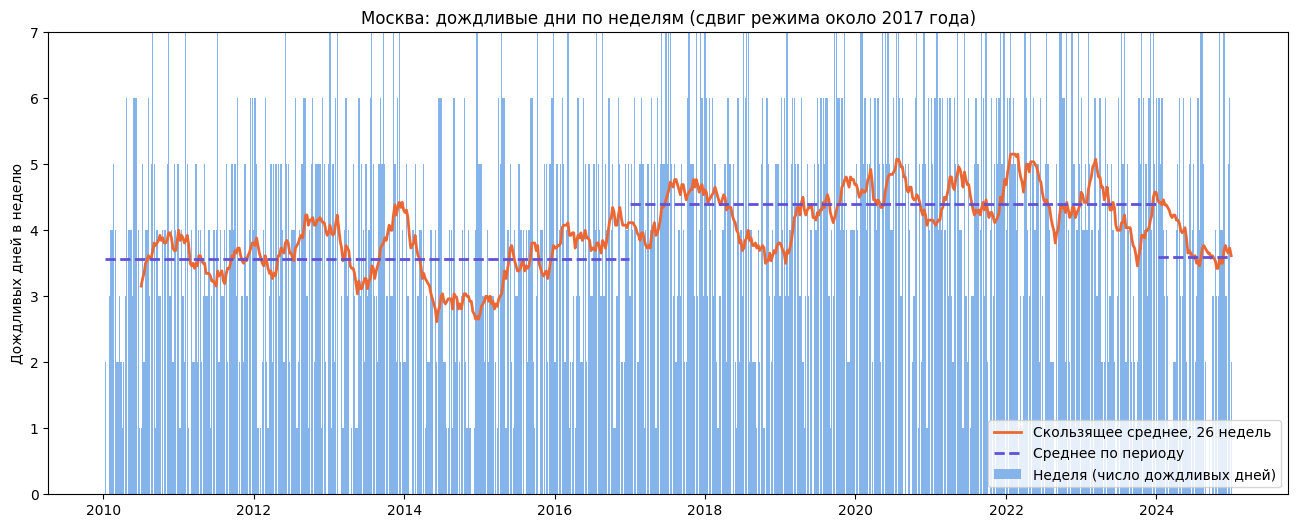

In [50]:
# Дневной ряд с датой в индексе (понадобится и дальше, потому что позже df теряет даты)
daily = df.set_index(df['date'].dt.normalize())['rain'].astype(float).asfreq('D')

# Недельная агрегация: число дождливых дней за неделю (берём только полные недели)
weekly = daily.resample('W-SUN').agg(['sum', 'count'])
weekly = weekly[weekly['count'] == 7]['sum']

# Скользящее среднее за 26 недель (≈ полгода) и среднее по трём периодам
rolling26 = weekly.rolling(26).mean()
periods = [('2010-01-01', '2016-12-31'), ('2017-01-01', '2023-12-31'), ('2024-01-01', '2024-12-31')]

plt.figure(figsize=(16, 6))
plt.bar(weekly.index, weekly.values, width=6, color='#85b4ea', label='Неделя (число дождливых дней)')
plt.plot(rolling26.index, rolling26.values, color='#eb6834', lw=2, label='Скользящее среднее, 26 недель')
for i, (start, end) in enumerate(periods):
    part = weekly[start:end]
    plt.hlines(part.mean(), part.index[0], part.index[-1], colors='#6250d6', linestyles='--', lw=2,
               label='Среднее по периоду' if i == 0 else None)
    print(f'{start[:4]}–{end[:4]}: {part.mean():.2f} дождливых дней в неделю')
plt.ylim(0, 7)
plt.ylabel('Дождливых дней в неделю')
plt.title('Москва: дождливые дни по неделям (сдвиг режима около 2017 года)')
plt.legend(loc='lower right')
plt.show()

## 7. Отбор признаков
Оставляем только нужное: дату, `day`, `month`, `year` и `rain`. Дату делаем индексом, чтобы красиво вывести таблицу.
Год сдвигаем на 2010 (`year - 2010`), чтобы он стал маленьким числом 0, 1, 2… — так нейросеть и масштабирование работают устойчивее.

In [51]:
# Keep only necessary columns
df = df[['date', 'day', 'month', 'year', 'rain']]
df = df.set_index('date')

# Reset year to start from 2010 (for better feature scaling)
df.year = df.year - 2010

# Display the processed DataFrame
print(df.head())

            day  month  year  rain
date                              
2010-01-01    1      1     0     0
2010-01-02    2      1     0     0
2010-01-03    3      1     0     0
2010-01-04    4      1     0     0
2010-01-05    5      1     0     0


In [52]:
# Drop date index
df = df.reset_index(drop=True)
df.tail()

,day,month,year,rain
5474,27,12,14,0
5475,28,12,14,0
5476,29,12,14,0
5477,30,12,14,1
5478,31,12,14,1


## 8. Разбиение на обучающую и тестовую выборки (для ARIMA)
Индекс даты сбрасываем и делим ряд **по времени**: первые 95% дней — обучение, последние 5% — тест.
Перемешивать нельзя: у временного ряда порядок важен, иначе модель «подсмотрит» будущее.

In [53]:
# Split the data for training and testing ARIMA model
train_size = int(len(df) * 0.95)
train, test = df['rain'][:train_size], df['rain'][train_size:]

## 9. Обучение ARIMA
**ARIMA(p, d, q)** — классическая модель, предсказывающая значение по прошлым значениям и прошлым ошибкам:
- `p=2` — смотрим на 2 предыдущих значения (авторегрессия);
- `d=0` — ряд не дифференцируем (считаем, что он уже стационарный);
- `q=2` — учитываем 2 предыдущие ошибки прогноза (скользящее среднее).

Модель обучается только на `train`, ей подаётся один столбец `rain`.

In [54]:
# Train the ARIMA model
arima_model = ARIMA(train, order=(2, 0, 2))  # Adjust order if needed
arima_model_fit = arima_model.fit()

## 10. Оценка ARIMA
Просим прогноз на период тестовой выборки. ARIMA возвращает не 0/1, а число (что-то вроде «вероятности»),
поэтому округляем по порогу 0.5: больше 0.5 → «дождь», иначе → «нет». Считаем **accuracy** — долю совпавших дней.
Это наш бейзлайн

In [55]:
# Forecast and evaluate the ARIMA model
arima_pred = arima_model_fit.predict(start=len(train), end=len(train) + len(test) - 1)
arima_pred_binary = np.where(arima_pred > 0.5, 1, 0)
print("ARIMA Accuracy:", accuracy_score(test, arima_pred_binary))

ARIMA Accuracy: 0.5437956204379562


## 10а. Проблема: ARIMA оценивается нечестно
Выше мы просили у ARIMA прогноз **сразу на весь оставшийся период** (≈270 дней вперёд), ни разу не показывая ей реальные значения из теста. Такой прогноз быстро «схлопывается» к среднему.

Сравним со следующими ориентирами:
- **мажоритарный базис** — всегда предсказывать самый частый класс;
- **ROC-AUC** — показывает, умеет ли модель вообще отличать дождливые дни от сухих (0.5 = случайность, меньше 0.5 = хуже случайной).

In [56]:
from sklearn.metrics import roc_auc_score, brier_score_loss

y = daily                      # дневной ряд rain с датами в индексе
split = len(train)             # граница train/test
y_test = test.values

baseline_acc = max(y_test.mean(), 1 - y_test.mean())
print(f'Мажоритарный базис: accuracy = {baseline_acc:.3f}')
print(f'ARIMA, многошаговый прогноз: accuracy = {accuracy_score(y_test, arima_pred_binary):.3f}, '
      f'ROC-AUC = {roc_auc_score(y_test, arima_pred):.3f}')
print('Разброс прогнозов от', round(float(arima_pred.min()), 3), 'до', round(float(arima_pred.max()), 3),
      '— почти константа')

Мажоритарный базис: accuracy = 0.547
ARIMA, многошаговый прогноз: accuracy = 0.544, ROC-AUC = 0.471
Разброс прогнозов от 0.388 до 0.567 — почти константа


## 10б. Правка 1: прогноз на один шаг вперёд
LSTM для каждого дня видит **реальные** предыдущие 20 дней. Дадим ту же информацию и ARIMA: параметры обучаем на `train`, а затем прогоняем модель по всему ряду методом `apply(..., refit=False)`. Параметры не переобучаются, но модель на каждом шаге учитывает **реальные** вчерашние значения и ошибки.

In [57]:
y_train = y.iloc[:split]

arima_1 = ARIMA(y_train, order=(2, 0, 2)).fit()
arima_1_full = arima_1.apply(y, refit=False)       # те же параметры, но на реальных данных
pred_1step = arima_1_full.get_prediction(start=split, end=len(y) - 1).predicted_mean.values

print(f'ARIMA(2,0,2), 1 шаг вперёд: accuracy = {accuracy_score(y_test, pred_1step > 0.5):.3f}, '
      f'ROC-AUC = {roc_auc_score(y_test, pred_1step):.3f}, Brier = {brier_score_loss(y_test, np.clip(pred_1step, 0, 1)):.3f}')

ARIMA(2,0,2), 1 шаг вперёд: accuracy = 0.704, ROC-AUC = 0.730, Brier = 0.207


## 10в. Проверка на нескольких годах (rolling origin)
Один тест из ≈270 дней слишком мал и зависит от сдвига режима, поэтому используем **скользящую проверку**: для каждого года 2020–2024 обучаемся на всём, что было **до** этого года, и тестируем на самом году. Получаем 5 независимых оценок и можем посмотреть и среднее, и разброс.

In [59]:
folds = [(pd.Timestamp(f'{yr}-01-01'), pd.Timestamp(f'{yr}-12-31')) for yr in range(2020, 2025)]
rows = []

for start, end in folds:
    k = y.index.get_loc(start)                      # размер обучающей части
    stop = y.index.get_loc(end) + 1
    y_f = y.iloc[k:stop].values

    fit = ARIMA(y.iloc[:k], order=(2, 0, 2)).fit()
    p = fit.apply(y, refit=False).get_prediction(start=k, end=stop - 1).predicted_mean.values
    rows.append({'год': start.year,
                 'базис (всегда частый класс)': max(y_f.mean(), 1 - y_f.mean()),
                 'ARIMA 1 шаг, accuracy': accuracy_score(y_f, p > 0.5),
                 'ARIMA 1 шаг, ROC-AUC': roc_auc_score(y_f, p)})

cv_table = pd.DataFrame(rows).set_index('год')
cv_table.loc['среднее'] = cv_table.mean()
cv_table.round(3)

### Что мы выяснили про ARIMA
- **Весь выигрыш даёт честная постановка:** прогноз на один шаг вперёд вместо многошагового поднимает accuracy с уровня базиса (≈0.55) до ≈0.70, а ROC-AUC с ≈0.47 (хуже случайного) до ≈0.70. Усреднённо по 2020–2024 это ≈0.70 против ≈0.62 у базиса.
- **Усложнения не помогли.** Мы пробовали годовую сезонность (гармоники Фурье), индикатор сдвига режима, другие порядки (p, q), подбор порога и даже логистическую регрессию на лагах за 14 дней: везде получались те же ≈0.70 accuracy и ≈0.70 AUC, разница в пределах шума. Поэтому в блокноте оставлена простая ARIMA(2,0,2).
- **Потолок задан данными:** заметная автокорреляция есть только на 1–2 лага (≈0.33 и ≈0.17), то есть по одной истории дождей завтра предсказывается слабо. Чтобы пойти дальше, нужны **новые признаки** (давление, влажность, температура, ветер), а не более хитрая ARIMA.

Теперь можно честно сравнивать с LSTM ниже: у неё тоже один шаг вперёд.

## 11. Подготовка данных для LSTM: новое разбиение
Снова делим по времени 95% / 5%, но теперь берём **всю таблицу** (`day`, `month`, `year`, `rain`), а не один столбец:
нейросеть будет использовать несколько признаков.

In [60]:
# Preparing data for LSTM model
train_size = int(len(df) * 0.95)
train = df.iloc[:train_size]
test = df.iloc[train_size:]

## 12. Масштабирование и нарезка на окна
1. **MinMaxScaler** приводит все признаки к диапазону [0, 1]. Масштабатор обучается только на `train` и лишь применяется к `test`, чтобы не было утечки информации из будущего.
2. **`create_sequences`** режет ряд на скользящие окна: вход — последние `seq_length = 20` дней со всеми признаками, ответ — значение `rain` на **следующий** день.

Получаются `X_train` / `X_test` формы *(примеры, 20 дней, 4 признака)* и целевые `y_train` / `y_test`.

In [61]:
# Select features for LSTM
features = ['day', 'month', 'year', 'rain']

# Scale the data
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train[features])
test_scaled = scaler.transform(test[features])

# Function to create sequences for LSTM
def create_sequences(data, seq_length=5):
    """Create sequences of features for LSTM."""
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length, :])  # Include all features in the sequence
        y.append(data[i+seq_length, -1])   # Target is 'rain' (last feature in scaled data)
    return np.array(X), np.array(y)

# Create sequences for training and testing
seq_length = 20
X_train, y_train = create_sequences(train_scaled, seq_length)
X_test, y_test = create_sequences(test_scaled, seq_length)

## 13. Своя функция активации `OptimA`
Это кастомный слой Keras с пятью **обучаемыми параметрами** (`alpha`, `beta`, `gamma`, `delta`, `lambda`).
Он комбинирует `tanh`, `softplus` и `sigmoid`, и сеть сама подбирает форму активации в процессе обучения.
Идея взята из стороннего репозитория (ссылка в комментарии). Для понимания блокнота главное, что он просто заменяет стандартную активацию внутри LSTM.

**Прироста точности она не даёт.** Мы сравнили её со стандартной `tanh` на 5 сидах: accuracy ≈0.705 против ≈0.698, AUC ≈0.731 против ≈0.723. Разница в пределах шума (тест всего ≈270 дней). Слой оставлен без изменений, потому что замена не критична: датасет маленький, обучение занимает секунды, а отсутствие ускорения cuDNN (которое отключает кастомная активация) на такой задаче и такой видеокарте ничего не меняет. Если нужно проще и быстрее, достаточно написать `LSTM(64, input_shape=...)` без аргумента `activation`.

In [62]:
# Define custom activation functions
class OptimA(Layer):  # Optimal Activation - https://github.com/EmotionEngineer/OptimA
    def __init__(self, **kwargs):
        super(OptimA, self).__init__(**kwargs)

    def build(self, input_shape):
        # Defining trainable parameters
        self.alpha = self.add_weight(name='alpha', shape=(), initializer='ones', trainable=True)
        self.beta = self.add_weight(name='beta', shape=(), initializer=tf.keras.initializers.Constant(0.5), trainable=True)
        self.gamma = self.add_weight(name='gamma', shape=(), initializer='ones', trainable=True)
        self.delta = self.add_weight(name='delta', shape=(), initializer=tf.keras.initializers.Constant(0.5), trainable=True)
        self.lambda_ = self.add_weight(name='lambda', shape=(), initializer='ones', trainable=True)

    def call(self, x):
        term1 = self.alpha * tf.math.tanh(self.beta * x)
        term2 = self.gamma * tf.math.softplus(self.delta * x) * tf.math.sigmoid(self.lambda_ * x)
        return term1 + term2

## 14. Модель LSTM и её обучение
- **Веса классов** (`class_weight='balanced'`): если дней без дождя и с дождём разное количество, редкому классу даётся больший вес, чтобы модель не училась просто «всегда отвечать частым вариантом».
- **Архитектура**: слой `LSTM(64)` читает окно из 20 дней и «запоминает» важное, затем `Dense(1, sigmoid)` выдаёт вероятность дождя от 0 до 1.
- **Компиляция**: оптимизатор Adam, потеря `binary_crossentropy` (стандарт для бинарной классификации), метрика accuracy.
- **EarlyStopping**: обучение до 1000 эпох, но остановится, если `val_accuracy` не улучшается 20 эпох подряд, и вернёт лучшие веса.

⚠️ Валидация здесь идёт по тестовой выборке, поэтому итоговая accuracy получается чуть оптимистичной.

In [63]:
# Calculate class weights for handling imbalanced classes
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Convert class weights to a dictionary
class_weights = {i: class_weights_array[i] for i in range(len(class_weights_array))}

# Define the LSTM model architecture
model_lstm = Sequential([
    LSTM(64, input_shape=(seq_length, len(features)), activation=OptimA()),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])
model_lstm.compile(optimizer=Adam(learning_rate=0.001, beta_1=0.95, amsgrad=True), loss='binary_crossentropy', metrics=['accuracy'])

# Set up Early Stopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_accuracy',  # Metric to monitor
    patience=20,             # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True,  # Restore the weights of the best model
    verbose=1               # Verbose output for debugging
)

# Train the LSTM model with class weights and Early Stopping
model_lstm.fit(X_train, y_train, epochs=1000, batch_size=1024, 
                validation_data=(X_test, y_test), 
                class_weight=class_weights, 
                callbacks=[early_stopping])

Epoch 1/1000


/Users/nikitabaslykov/Documents/Python/ML - University/Без названия/SAI-Course/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.5142 - loss: 0.7289 - val_accuracy: 0.4685 - val_loss: 0.7340
Epoch 2/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4314 - loss: 0.7108 - val_accuracy: 0.7008 - val_loss: 0.6829
Epoch 3/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5967 - loss: 0.6856 - val_accuracy: 0.5315 - val_loss: 0.6821
Epoch 4/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5686 - loss: 0.6882 - val_accuracy: 0.5315 - val_loss: 0.6771
Epoch 5/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6299 - loss: 0.6811 - val_accuracy: 0.6732 - val_loss: 0.6774
Epoch 6/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4685 - loss: 0.6814 - val_accuracy: 0.5157 - val_loss: 0.6805
Epoch 7/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4390 - loss: 0.6815 - val_accuracy: 0.6535 - val_loss: 0.6740
Epoch 8/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5607 - loss: 0.6756 - val_accuracy: 0.6929 - val_loss: 0.66

## 15. Оценка LSTM
Получаем вероятности на тесте, округляем по порогу 0.5 в классы 0/1 и считаем accuracy — так же, как для ARIMA, чтобы модели можно было сравнить напрямую.
Если accuracy около 0.5–0.6, это почти уровень случайного угадывания: по календарным признакам и прошлым дождям погоду предсказать трудно.

In [64]:
# Make predictions with the LSTM model
predictions = model_lstm.predict(X_test)
forecast_lstm = (predictions > 0.5).astype(int).flatten()  # Threshold to classify as 0 or 1

# Evaluate the LSTM model accuracy
accuracy_lstm = accuracy_score(y_test, forecast_lstm)
print("LSTM Model Accuracy with Additional Features:", accuracy_lstm)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
LSTM Model Accuracy with Additional Features: 0.7007874015748031


## 16. Прогноз ARIMA на следующий день
Просим у ARIMA прогноз на один шаг сразу после тестовой выборки и округляем по порогу 0.5: `1` — дождь, `0` — нет.
Модель обучалась только на `train`, поэтому прогноз делается «издалека» и, скорее всего, почти равен среднему значению ряда.

In [65]:
# Forecast the next day after the test set
next_day_pred_arima = arima_model_fit.predict(start=len(train) + len(test), end=len(train) + len(test)).iloc[0]
next_day_pred_binary_arima = 1 if next_day_pred_arima > 0.5 else 0
print("Next day ARIMA prediction (0 = No Rain, 1 = Rain):", next_day_pred_binary_arima)

Next day ARIMA prediction (0 = No Rain, 1 = Rain): 1


## 16б. Прогноз ARIMA на следующий день (на один шаг, как в 10б)
Старый прогноз выше делался многошаговой ARIMA, обученной на `train`, поэтому он почти равен среднему. Здесь ARIMA обучена на **всём** ряде, и мы просим прогноз ровно на один день после его конца, когда известны все реальные предыдущие значения.

In [66]:
arima_final = ARIMA(y, order=(2, 0, 2)).fit()

p_next = float(arima_final.forecast(steps=1).iloc[0])
print(f'Дата прогноза: {(y.index[-1] + pd.Timedelta(days=1)).date()}')
print(f'Вероятность дождя по ARIMA: {p_next:.2f} → {"дождь" if p_next > 0.5 else "без дождя"} (1 = дождь, 0 = нет)')

## 17. Прогноз LSTM на следующий день
Берём **последние 20 дней** тестовой выборки (то есть последнее окно), добавляем ось батча (`expand_dims`) и просим у сети прогноз.
Вероятность больше 0.5 → «дождь», иначе → «нет». В конце сравниваем ответы обеих моделей на завтра.

In [67]:
# Get the last sequence from the test set for prediction
last_sequence = test_scaled[-seq_length:]  # Extract last 'seq_length' data points
last_sequence = np.expand_dims(last_sequence, axis=0)  # Reshape to match model input shape

# Predict the next day using LSTM
next_day_pred_lstm = model_lstm.predict(last_sequence)
next_day_pred_binary_lstm = 1 if next_day_pred_lstm > 0.5 else 0
print("Next day LSTM prediction (0 = No Rain, 1 = Rain):", next_day_pred_binary_lstm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Next day LSTM prediction (0 = No Rain, 1 = Rain): 1
